In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
project_root = os.path.abspath("..")
sys.path.append(project_root)

print("Added to PYTHONPATH:", project_root)

Added to PYTHONPATH: /vols/cms/mm1221/geant4sim/scripts/validation_new


In [2]:
import pandas as pd
import glob
import os
from pathlib import Path

def load_csv_folder_with_event_offset(folder, event_col="event_id", verbose=True):
    """
    Recursively loads ALL CSVs inside `folder` and subfolders.
    Applies a running offset to event_id so events remain unique across files.
    """

    # --- recursively find csv files ---
    pattern = os.path.join(folder, "**", "*.csv")
    csv_files = glob.glob(pattern, recursive=True)

    if len(csv_files) == 0:
        raise RuntimeError(f"No CSV files found anywhere under {folder}")

    # --- sort in stable, natural path order ---
    csv_files = sorted(csv_files, key=lambda p: Path(p).as_posix())

    if verbose:
        print(f"Found {len(csv_files)} csv files")

    dfs = []
    event_offset = 0
    total_events = 0

    for i, f in enumerate(csv_files):
        if verbose and (i % 20 == 0):
            print(f"[{i+1}/{len(csv_files)}] Loading: {f}")

        df = pd.read_csv(f)

        if event_col not in df.columns:
            raise ValueError(f"{event_col} not found in {f}")

        # --- count events BEFORE offset ---
        n_events = df[event_col].nunique()

        # --- apply offset ---
        df[event_col] += event_offset

        dfs.append(df)

        event_offset += n_events
        total_events += n_events

    if verbose:
        print(f"Total unique events loaded: {total_events}")
        print(f"Final event_id range: 0 → {event_offset-1}")

    return pd.concat(dfs, ignore_index=True)

In [8]:
df_contrastive = load_csv_folder_with_event_offset("../csv_EM/contk22_2_10/")
df_oc          = load_csv_folder_with_event_offset("../csv_EM/oc_t025_2_10/")
df_oc_Ag          = load_csv_folder_with_event_offset("../csv_EM/ocA8_2_10")
df_oc_noise = load_csv_folder_with_event_offset("../csv_EM/cont_oc_2_10/")

#df_oc_Ag = df_oc

print(df_contrastive["event_id"].min(), df_contrastive["event_id"].max())
print(df_oc["event_id"].min(), df_oc["event_id"].max())
print(df_oc_Ag["event_id"].min(), df_oc_Ag["event_id"].max())
print(df_oc_noise["event_id"].min(), df_oc_noise["event_id"].max())

Found 200 csv files
[1/200] Loading: ../csv_EM/contk22_2_10/Electron.10001_10002.csv
[21/200] Loading: ../csv_EM/contk22_2_10/Electron.10041_10042.csv
[41/200] Loading: ../csv_EM/contk22_2_10/Electron.10081_10082.csv
[61/200] Loading: ../csv_EM/contk22_2_10/Electron.10121_10122.csv
[81/200] Loading: ../csv_EM/contk22_2_10/Electron.10161_10162.csv
[101/200] Loading: ../csv_EM/contk22_2_10/Electron.10201_10202.csv
[121/200] Loading: ../csv_EM/contk22_2_10/Electron.10241_10242.csv
[141/200] Loading: ../csv_EM/contk22_2_10/Electron.10281_10282.csv
[161/200] Loading: ../csv_EM/contk22_2_10/Electron.10321_10322.csv
[181/200] Loading: ../csv_EM/contk22_2_10/Electron.10361_10362.csv
Total unique events loaded: 10000
Final event_id range: 0 → 9999
Found 200 csv files
[1/200] Loading: ../csv_EM/oc_t025_2_10/Electron.10001_10002.csv
[21/200] Loading: ../csv_EM/oc_t025_2_10/Electron.10041_10042.csv
[41/200] Loading: ../csv_EM/oc_t025_2_10/Electron.10081_10082.csv
[61/200] Loading: ../csv_EM/oc_t02

In [9]:
from src.metrics.calculations import calc_purity, calc_efficiency
import numpy as np

# ============================
# 1) Efficiency binning (unchanged)
# ============================

all_cp = df_contrastive["PrimaryEnergy"].values

n_bins = 10
cp_bins = np.linspace(all_cp.min(), all_cp.max(), n_bins + 1)
cp_bin_centers = 0.5 * (cp_bins[:-1] + cp_bins[1:])

eff_contrastive = []
eff_oc = []
eff_oc_Ag = []
eff_oc_noise = []

for i in range(n_bins):
    low, high = cp_bins[i], cp_bins[i + 1]

    df_c_bin = df_contrastive[
        (df_contrastive["PrimaryEnergy"] >= low) &
        (df_contrastive["PrimaryEnergy"] < high)
    ]
    df_oc_bin = df_oc[
        (df_oc["PrimaryEnergy"] >= low) &
        (df_oc["PrimaryEnergy"] < high)
    ]
    df_oc_Ag_bin = df_oc_Ag[
        (df_oc_Ag["PrimaryEnergy"] >= low) &
        (df_oc_Ag["PrimaryEnergy"] < high)
    ]
    df_oc_noise_bin = df_oc_noise[
        (df_oc_noise["PrimaryEnergy"] >= low) &
        (df_oc_noise["PrimaryEnergy"] < high)
    ]

    eff_contrastive.append(calc_efficiency(df_c_bin, threshold=0.7))
    eff_oc.append(calc_efficiency(df_oc_bin, threshold=0.7))
    eff_oc_Ag.append(calc_efficiency(df_oc_Ag_bin, threshold=0.7))
    eff_oc_noise.append(calc_efficiency(df_oc_noise_bin, threshold=0.7))


# ============================
# 2) Purity vs CP-energy binning (NEW LOGIC)
# ============================

EVENT_COL = "event_id"
RECO_ID_COL = "reco_id"
CP_ID_COL = "cp_id"
RTS_COL = "RtS"          # change if needed
CP_E_COL = "PrimaryEnergy"

def attach_best_cp_energy(df,
                          *,
                          event_col=EVENT_COL,
                          reco_col=RECO_ID_COL,
                          cp_col=CP_ID_COL,
                          rts_col=RTS_COL,
                          cp_energy_col=CP_E_COL):
    """
    One row per (event_id, reco_id):
      choose cp_id with MINIMUM RtS, attach that cp's energy as matched_cp_energy.
    """
    needed = {event_col, reco_col, cp_col, rts_col, cp_energy_col}
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"attach_best_cp_energy missing columns: {missing}")

    d = df[[event_col, reco_col, cp_col, rts_col, cp_energy_col]].copy()
    d = d[np.isfinite(d[rts_col].to_numpy()) & np.isfinite(d[cp_energy_col].to_numpy())]

    # idx of best cp per reco (min RtS)
    idx = d.groupby([event_col, reco_col], sort=False)[rts_col].idxmin()
    best = d.loc[idx, [event_col, reco_col, cp_col, rts_col, cp_energy_col]].copy()
    best = best.rename(columns={cp_energy_col: "matched_cp_energy"})
    return best

def filter_df_to_reco_set(df, reco_set_df, *, event_col=EVENT_COL, reco_col=RECO_ID_COL):
    """
    Keep only association rows for the reco objects in reco_set_df (identified by event_id,reco_id).
    """
    return df.merge(reco_set_df[[event_col, reco_col]], on=[event_col, reco_col], how="inner")

# best-match maps: one row per reco object
best_c     = attach_best_cp_energy(df_contrastive)
best_oc    = attach_best_cp_energy(df_oc)
best_oc_Ag = attach_best_cp_energy(df_oc_Ag)
best_noise = attach_best_cp_energy(df_oc_noise)

purity_contrastive = []
purity_oc = []
purity_oc_Ag = []
purity_oc_noise = []

for i in range(n_bins):
    low, high = cp_bins[i], cp_bins[i + 1]

    # reco objects whose best-matched CP energy falls in this CP-energy bin
    sel_c     = best_c[(best_c["matched_cp_energy"] >= low) & (best_c["matched_cp_energy"] < high)]
    sel_oc    = best_oc[(best_oc["matched_cp_energy"] >= low) & (best_oc["matched_cp_energy"] < high)]
    sel_oc_Ag = best_oc_Ag[(best_oc_Ag["matched_cp_energy"] >= low) & (best_oc_Ag["matched_cp_energy"] < high)]
    sel_noise = best_noise[(best_noise["matched_cp_energy"] >= low) & (best_noise["matched_cp_energy"] < high)]

    # keep ALL cp association rows for those reco objects (so purity is computed correctly)
    df_c_bin     = filter_df_to_reco_set(df_contrastive, sel_c)
    df_oc_bin    = filter_df_to_reco_set(df_oc,          sel_oc)
    df_oc_Ag_bin = filter_df_to_reco_set(df_oc_Ag,       sel_oc_Ag)
    df_noise_bin = filter_df_to_reco_set(df_oc_noise,    sel_noise)

    purity_contrastive.append(calc_purity(df_c_bin, threshold=0.2) if len(df_c_bin) else np.nan)
    purity_oc.append(         calc_purity(df_oc_bin, threshold=0.2) if len(df_oc_bin) else np.nan)
    purity_oc_Ag.append(      calc_purity(df_oc_Ag_bin, threshold=0.2) if len(df_oc_Ag_bin) else np.nan)
    purity_oc_noise.append(   calc_purity(df_noise_bin, threshold=0.2) if len(df_noise_bin) else np.nan)

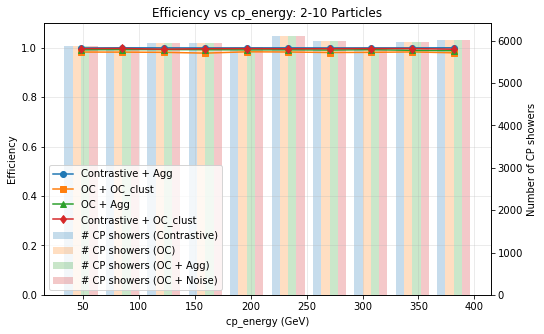

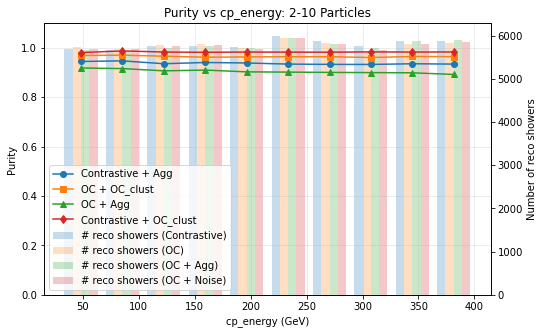

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def _bin_index(values, bins):
    """Return bin indices 0..(nbins-1) using [low, high) convention."""
    v = np.asarray(values)
    idx = np.digitize(v, bins, right=False) - 1
    valid = np.isfinite(v) & (idx >= 0) & (idx < len(bins) - 1)
    return idx[valid]

def counts_per_bin_unique(df, value_col, bins, *, event_col="event_id", id_col=None, mask=None):
    """
    Count UNIQUE objects per bin.
    - If id_col is provided: count unique (event_id, id_col) objects per bin.
    """
    cols = [value_col]
    if event_col in df.columns:
        cols.append(event_col)
    if id_col is not None:
        cols.append(id_col)

    if mask is not None:
        d = df.loc[mask, cols]
    else:
        d = df[cols]

    d = d[np.isfinite(d[value_col].to_numpy())]

    if id_col is not None:
        if event_col not in d.columns:
            raise ValueError(f"event_col='{event_col}' not in df columns; needed to count unique objects per event.")
        d = d.drop_duplicates(subset=[event_col, id_col])

    idx = _bin_index(d[value_col].to_numpy(), bins)
    return np.bincount(idx, minlength=len(bins) - 1)


# ============================
# Efficiency plot + CP histogram background
# ============================

EVENT_COL = "event_id"
CP_ID_COL = "cp_id"

cp_counts_c     = counts_per_bin_unique(df_contrastive, "PrimaryEnergy", cp_bins, event_col=EVENT_COL, id_col=CP_ID_COL)
cp_counts_oc    = counts_per_bin_unique(df_oc,          "PrimaryEnergy", cp_bins, event_col=EVENT_COL, id_col=CP_ID_COL)
cp_counts_ocA   = counts_per_bin_unique(df_oc_Ag,       "PrimaryEnergy", cp_bins, event_col=EVENT_COL, id_col=CP_ID_COL)
cp_counts_noise = counts_per_bin_unique(df_oc_noise,    "PrimaryEnergy", cp_bins, event_col=EVENT_COL, id_col=CP_ID_COL)

cp_bin_centers_GeV = cp_bin_centers / 1000.0
cp_bin_widths_GeV  = (cp_bins[1:] - cp_bins[:-1]) / 1000.0

fig, ax = plt.subplots(figsize=(8, 5))
ax_counts = ax.twinx()

step  = 0.20 * cp_bin_widths_GeV
bar_w = 0.20 * cp_bin_widths_GeV

ax_counts.bar(cp_bin_centers_GeV - 1.5*step, cp_counts_c,     width=bar_w, alpha=0.25, label="# CP showers (Contrastive)")
ax_counts.bar(cp_bin_centers_GeV - 0.5*step, cp_counts_oc,    width=bar_w, alpha=0.25, label="# CP showers (OC)")
ax_counts.bar(cp_bin_centers_GeV + 0.5*step, cp_counts_ocA,   width=bar_w, alpha=0.25, label="# CP showers (OC + Agg)")
ax_counts.bar(cp_bin_centers_GeV + 1.5*step, cp_counts_noise, width=bar_w, alpha=0.25, label="# CP showers (OC + Noise)")

ax.set_zorder(2)
ax.patch.set_alpha(0.0)
ax_counts.set_zorder(1)

ax.plot(cp_bin_centers_GeV, eff_contrastive, "o-", label="Contrastive + Agg")
ax.plot(cp_bin_centers_GeV, eff_oc,          "s-", label="OC + OC_clust")
ax.plot(cp_bin_centers_GeV, eff_oc_Ag,       "^-", label="OC + Agg")
ax.plot(cp_bin_centers_GeV, eff_oc_noise,    "d-", label="Contrastive + OC_clust")

ax.set_xlabel("cp_energy (GeV)")
ax.set_ylabel("Efficiency")
ax.set_title("Efficiency vs cp_energy: 2-10 Particles")
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3)

ax_counts.set_ylabel("Number of CP showers")

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_counts.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="best")

plt.show()


# ============================
# Purity plot + RECO histogram background (BUT BINNED BY matched CP energy)
# ============================

# We want reco shower counts per CP-energy bin:
# count unique reco_id, but place them into bins via matched CP energy (min RtS match).
# We'll use best_* computed in Cell 1 (one row per reco object with matched_cp_energy).

RECO_ID_COL = "reco_id"

def reco_counts_from_best(best_df, cp_bins, *, event_col="event_id", reco_col="reco_id"):
    """
    Count unique reco objects per CP-energy bin using best_df (one row per reco object).
    """
    d = best_df[[event_col, reco_col, "matched_cp_energy"]].copy()
    d = d[np.isfinite(d["matched_cp_energy"].to_numpy())]
    d = d.drop_duplicates(subset=[event_col, reco_col])
    idx = _bin_index(d["matched_cp_energy"].to_numpy(), cp_bins)
    return np.bincount(idx, minlength=len(cp_bins) - 1)

reco_counts_c     = reco_counts_from_best(best_c,     cp_bins, event_col=EVENT_COL, reco_col=RECO_ID_COL)
reco_counts_oc    = reco_counts_from_best(best_oc,    cp_bins, event_col=EVENT_COL, reco_col=RECO_ID_COL)
reco_counts_ocA   = reco_counts_from_best(best_oc_Ag, cp_bins, event_col=EVENT_COL, reco_col=RECO_ID_COL)
reco_counts_noise = reco_counts_from_best(best_noise, cp_bins, event_col=EVENT_COL, reco_col=RECO_ID_COL)

fig, ax = plt.subplots(figsize=(8, 5))
ax_counts = ax.twinx()

step  = 0.20 * cp_bin_widths_GeV
bar_w = 0.20 * cp_bin_widths_GeV

ax_counts.bar(cp_bin_centers_GeV - 1.5*step, reco_counts_c,     width=bar_w, alpha=0.25, label="# reco showers (Contrastive)")
ax_counts.bar(cp_bin_centers_GeV - 0.5*step, reco_counts_oc,    width=bar_w, alpha=0.25, label="# reco showers (OC)")
ax_counts.bar(cp_bin_centers_GeV + 0.5*step, reco_counts_ocA,   width=bar_w, alpha=0.25, label="# reco showers (OC + Agg)")
ax_counts.bar(cp_bin_centers_GeV + 1.5*step, reco_counts_noise, width=bar_w, alpha=0.25, label="# reco showers (OC + Noise)")

ax.set_zorder(2)
ax.patch.set_alpha(0.0)
ax_counts.set_zorder(1)

ax.plot(cp_bin_centers_GeV, purity_contrastive, "o-", label="Contrastive + Agg")
ax.plot(cp_bin_centers_GeV, purity_oc,          "s-", label="OC + OC_clust")
ax.plot(cp_bin_centers_GeV, purity_oc_Ag,       "^-", label="OC + Agg")
ax.plot(cp_bin_centers_GeV, purity_oc_noise,    "d-", label="Contrastive + OC_clust")

ax.set_xlabel("cp_energy (GeV)")
ax.set_ylabel("Purity")
ax.set_title("Purity vs cp_energy: 2-10 Particles")
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3)

ax_counts.set_ylabel("Number of reco showers")

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_counts.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="best")

plt.show()

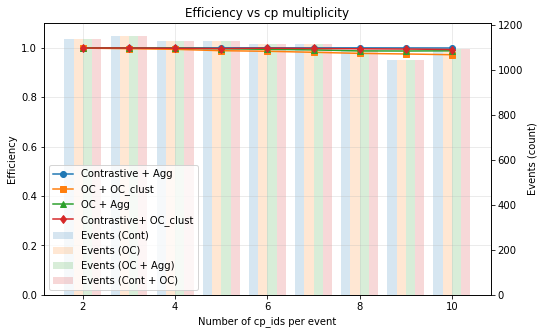

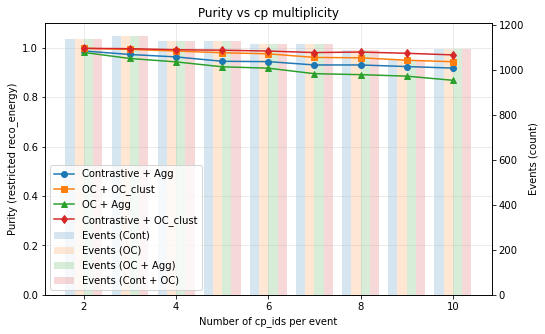

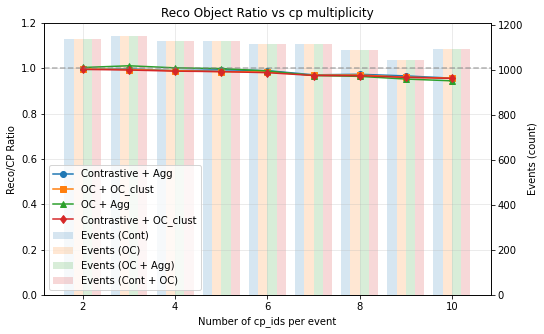

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from src.metrics.calculations import calc_purity, calc_efficiency, calc_ratio

# ----------------------------
# 0) CP multiplicity per event (do it ONCE, using contrastive as reference)
# ----------------------------
cp_per_event = (
    df_contrastive[["event_id", "cp_id"]]
    .drop_duplicates()
    .groupby("event_id")["cp_id"]
    .nunique()
)

multiplicities = np.sort(cp_per_event.unique())

# ----------------------------
# Helper: multiplicity histogram PER dataframe (independent)
# ----------------------------
def multiplicity_hist_for_df(df, *, event_col="event_id", cp_col="cp_id"):
    cp_per_evt = (
        df[[event_col, cp_col]]
        .drop_duplicates()
        .groupby(event_col)[cp_col]
        .nunique()
    )
    m_vals = cp_per_evt.values.astype(int)
    m_min, m_max = int(m_vals.min()), int(m_vals.max())
    edges = np.arange(m_min - 0.5, m_max + 1.5, 1.0)  # integer-centered bins
    counts, edges = np.histogram(m_vals, bins=edges)
    return counts, edges

# Compute independent histograms for each curve
hist_counts_c,     hist_edges_c     = multiplicity_hist_for_df(df_contrastive)
hist_counts_oc,    hist_edges_oc    = multiplicity_hist_for_df(df_oc)
hist_counts_ag,    hist_edges_ag    = multiplicity_hist_for_df(df_oc_Ag)
hist_counts_noise, hist_edges_noise = multiplicity_hist_for_df(df_oc_noise)

# ----------------------------
# Helper: add 4-bar multiplicity histogram background (independent per df)
# ----------------------------
def add_multiplicity_hist_background_4(ax,
                                      edges_c, counts_c,
                                      edges_oc, counts_oc,
                                      edges_ag, counts_ag,
                                      edges_noise, counts_noise,
                                      alpha=0.18):
    """
    Draw 4 independent histograms (4 bars per multiplicity bin) on a twin y-axis.
    Uses edge-based bars. Assumes integer-centered binning (k-0.5 .. k+0.5).
    """
    ax2 = ax.twinx()

    # Choose a common x-range so bars align visually across all four
    left_min  = min(edges_c[0], edges_oc[0], edges_ag[0], edges_noise[0])
    right_max = max(edges_c[-1], edges_oc[-1], edges_ag[-1], edges_noise[-1])
    common_edges = np.arange(left_min, right_max + 1e-9, 1.0)  # step = 1
    lefts = common_edges[:-1]

    def counts_on_common(edges, counts, common_edges):
        out = np.zeros(len(common_edges) - 1, dtype=float)
        for i in range(len(counts)):
            l = edges[i]
            j = int(round((l - common_edges[0]) / 1.0))
            if 0 <= j < len(out):
                out[j] = counts[i]
        return out

    c_common     = counts_on_common(edges_c,     counts_c,     common_edges)
    oc_common    = counts_on_common(edges_oc,    counts_oc,    common_edges)
    ag_common    = counts_on_common(edges_ag,    counts_ag,    common_edges)
    noise_common = counts_on_common(edges_noise, counts_noise, common_edges)

    # 4 bars per bin (centers at k +/- {1.5, 0.5}*step)
    step  = 0.20   # in "multiplicity units" since bin width is 1
    bar_w = 0.20

    centers = lefts + 0.5
    ax2.bar(centers - 1.5*step, c_common,     width=bar_w, alpha=alpha, label="Events (Cont)")
    ax2.bar(centers - 0.5*step, oc_common,    width=bar_w, alpha=alpha, label="Events (OC)")
    ax2.bar(centers + 0.5*step, ag_common,    width=bar_w, alpha=alpha, label="Events (OC + Agg)")
    ax2.bar(centers + 1.5*step, noise_common, width=bar_w, alpha=alpha, label="Events (Cont + OC)")

    ax2.set_ylabel("Events (count)")
    ax2.grid(False)

    # Put histogram behind lines
    ax2.set_zorder(0)
    ax.set_zorder(1)
    ax.patch.set_alpha(0.0)

    return ax2

# ----------------------------
# 1) Efficiency vs multiplicity (4 curves, independent selections)
# ----------------------------
eff_contrastive, eff_oc, eff_oc_Ag, eff_oc_noise = [], [], [], []

for m in multiplicities:
    event_ids_m = cp_per_event.index[cp_per_event == m]

    df_c_m     = df_contrastive[df_contrastive["event_id"].isin(event_ids_m)]
    df_oc_m    = df_oc[df_oc["event_id"].isin(event_ids_m)]
    df_ag_m    = df_oc_Ag[df_oc_Ag["event_id"].isin(event_ids_m)]
    df_noise_m = df_oc_noise[df_oc_noise["event_id"].isin(event_ids_m)]

    eff_contrastive.append(calc_efficiency(df_c_m,     threshold=0.7) if len(df_c_m)     else np.nan)
    eff_oc.append(         calc_efficiency(df_oc_m,    threshold=0.7) if len(df_oc_m)    else np.nan)
    eff_oc_Ag.append(      calc_efficiency(df_ag_m,    threshold=0.7) if len(df_ag_m)    else np.nan)
    eff_oc_noise.append(   calc_efficiency(df_noise_m, threshold=0.7) if len(df_noise_m) else np.nan)

# ----------------------------
# 2) Purity vs multiplicity (4 curves, independent restrictions)
# ----------------------------

LOW = 0
HIGH = 30000
df_c_res     = df_contrastive[(df_contrastive["reco_energy"] >= LOW) & (df_contrastive["reco_energy"] <= HIGH)]
df_oc_res    = df_oc[(df_oc["reco_energy"] >= LOW) & (df_oc["reco_energy"] <= HIGH)]
df_ag_res    = df_oc_Ag[(df_oc_Ag["reco_energy"] >= LOW) & (df_oc_Ag["reco_energy"] <= HIGH)]
df_noise_res = df_oc_noise[(df_oc_noise["reco_energy"] >= LOW) & (df_oc_noise["reco_energy"] <= HIGH)]

purity_contrastive, purity_oc, purity_oc_Ag, purity_oc_noise = [], [], [], []

for m in multiplicities:
    event_ids_m = cp_per_event.index[cp_per_event == m]

    df_c_m_r     = df_c_res[df_c_res["event_id"].isin(event_ids_m)]
    df_oc_m_r    = df_oc_res[df_oc_res["event_id"].isin(event_ids_m)]
    df_ag_m_r    = df_ag_res[df_ag_res["event_id"].isin(event_ids_m)]
    df_noise_m_r = df_noise_res[df_noise_res["event_id"].isin(event_ids_m)]

    purity_contrastive.append(calc_purity(df_c_m_r,     threshold=0.2) if len(df_c_m_r)     else np.nan)
    purity_oc.append(         calc_purity(df_oc_m_r,    threshold=0.2) if len(df_oc_m_r)    else np.nan)
    purity_oc_Ag.append(      calc_purity(df_ag_m_r,    threshold=0.2) if len(df_ag_m_r)    else np.nan)
    purity_oc_noise.append(   calc_purity(df_noise_m_r, threshold=0.2) if len(df_noise_m_r) else np.nan)

# ----------------------------
# 3) Number Ratio vs multiplicity (4 curves, independent)
# ----------------------------
ratio_contrastive, ratio_oc, ratio_oc_Ag, ratio_oc_noise = [], [], [], []

for m in multiplicities:
    event_ids_m = cp_per_event.index[cp_per_event == m]

    df_c_m     = df_contrastive[df_contrastive["event_id"].isin(event_ids_m)]
    df_oc_m    = df_oc[df_oc["event_id"].isin(event_ids_m)]
    df_ag_m    = df_oc_Ag[df_oc_Ag["event_id"].isin(event_ids_m)]
    df_noise_m = df_oc_noise[df_oc_noise["event_id"].isin(event_ids_m)]

    ratio_contrastive.append(calc_ratio(df_c_m)      if len(df_c_m)      else np.nan)
    ratio_oc.append(         calc_ratio(df_oc_m)     if len(df_oc_m)     else np.nan)
    ratio_oc_Ag.append(      calc_ratio(df_ag_m)     if len(df_ag_m)     else np.nan)
    ratio_oc_noise.append(   calc_ratio(df_noise_m)  if len(df_noise_m)  else np.nan)

# ----------------------------
# 4) Plots (each with 4 curves + 4-bar histogram background)
# ----------------------------

# Efficiency Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax_counts = add_multiplicity_hist_background_4(
    ax,
    hist_edges_c,     hist_counts_c,
    hist_edges_oc,    hist_counts_oc,
    hist_edges_ag,    hist_counts_ag,
    hist_edges_noise, hist_counts_noise,
    alpha=0.18,
)

ax.plot(multiplicities, eff_contrastive, "o-", label="Contrastive + Agg")
ax.plot(multiplicities, eff_oc,          "s-", label="OC + OC_clust")
ax.plot(multiplicities, eff_oc_Ag,       "^-", label="OC + Agg")
ax.plot(multiplicities, eff_oc_noise,    "d-", label="Contrastive+ OC_clust")

ax.set_xlabel("Number of cp_ids per event")
ax.set_ylabel("Efficiency")
ax.set_title("Efficiency vs cp multiplicity")
ax.set_ylim(0.0, 1.1)
ax.grid(True, alpha=0.3)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_counts.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="best")
plt.show()

# Purity Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax_counts = add_multiplicity_hist_background_4(
    ax,
    hist_edges_c,     hist_counts_c,
    hist_edges_oc,    hist_counts_oc,
    hist_edges_ag,    hist_counts_ag,
    hist_edges_noise, hist_counts_noise,
    alpha=0.18,
)

ax.plot(multiplicities, purity_contrastive, "o-", label="Contrastive + Agg")
ax.plot(multiplicities, purity_oc,          "s-", label="OC + OC_clust")
ax.plot(multiplicities, purity_oc_Ag,       "^-", label="OC + Agg")
ax.plot(multiplicities, purity_oc_noise,    "d-", label="Contrastive + OC_clust")

ax.set_xlabel("Number of cp_ids per event")
ax.set_ylabel("Purity (restricted reco_energy)")
ax.set_title("Purity vs cp multiplicity")
ax.set_ylim(0.0, 1.10)
ax.grid(True, alpha=0.3)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_counts.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="best")
plt.show()

# Number Ratio Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax_counts = add_multiplicity_hist_background_4(
    ax,
    hist_edges_c,     hist_counts_c,
    hist_edges_oc,    hist_counts_oc,
    hist_edges_ag,    hist_counts_ag,
    hist_edges_noise, hist_counts_noise,
    alpha=0.18,
)

ax.plot(multiplicities, ratio_contrastive, "o-", label="Contrastive + Agg")
ax.plot(multiplicities, ratio_oc,          "s-", label="OC + OC_clust")
ax.plot(multiplicities, ratio_oc_Ag,       "^-", label="OC + Agg")
ax.plot(multiplicities, ratio_oc_noise,    "d-", label="Contrastive + OC_clust")

ax.axhline(1.0, color="gray", linestyle="--", alpha=0.6)
ax.set_xlabel("Number of cp_ids per event")
ax.set_ylabel("Reco/CP Ratio")
ax.set_title("Reco Object Ratio vs cp multiplicity")

ymax = max(
    np.nanmax(ratio_contrastive),
    np.nanmax(ratio_oc),
    np.nanmax(ratio_oc_Ag),
    np.nanmax(ratio_oc_noise),
    1.2
)
ax.set_ylim(0.0, ymax)
ax.grid(True, alpha=0.3)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_counts.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="best")
plt.show()

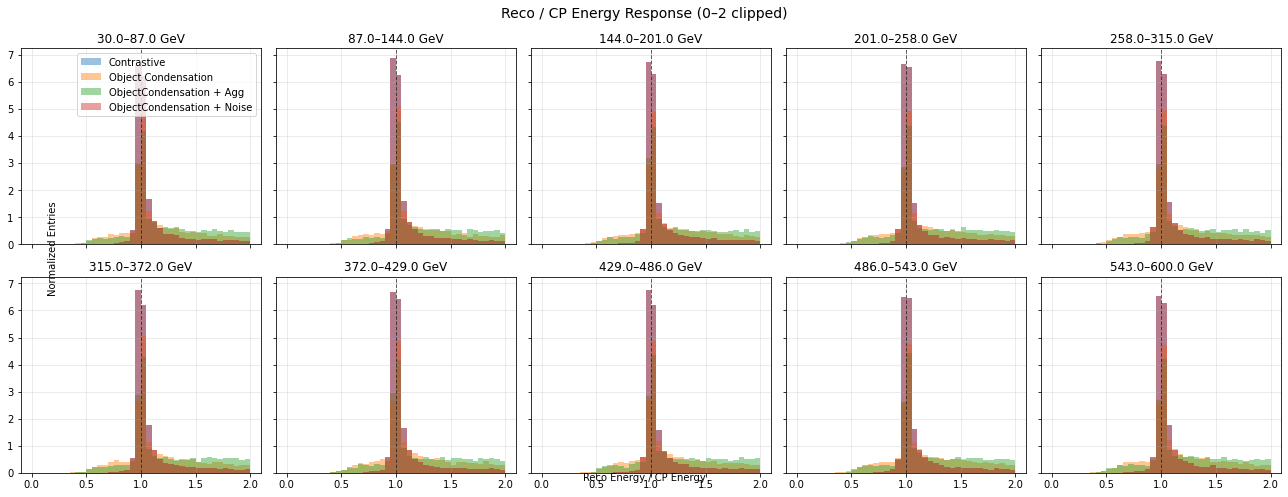

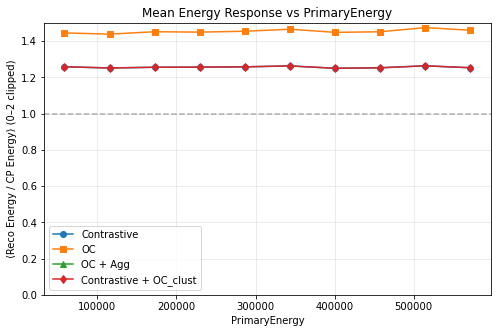

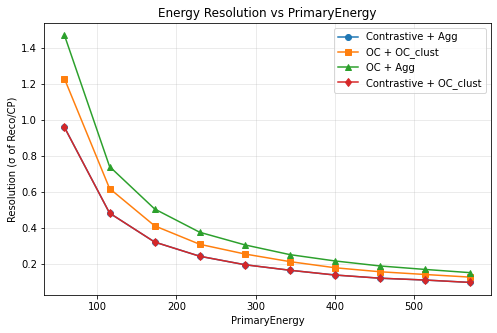

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Energy response vs PrimaryEnergy (Contrastive vs OC vs OC+Agg vs OC+Noise)
# Best-matched reco per CP (max shared_energy), clipped to [0, 2]
# Also computes RESOLUTION = width (std dev) per energy bin

# 1) Define PrimaryEnergy bins (include 4th df)

n_bins = 10

all_cp_energy = np.concatenate([
    df_contrastive["PrimaryEnergy"].values,
    df_oc["PrimaryEnergy"].values,
    df_oc_Ag["PrimaryEnergy"].values,
    df_oc_noise["PrimaryEnergy"].values,
])

energy_bins = np.linspace(all_cp_energy.min(), all_cp_energy.max(), n_bins + 1)
energy_bin_centers = 0.5 * (energy_bins[:-1] + energy_bins[1:])

# 2) Helper: compute response + mean + resolution

def response_by_energy_bin(
    df,
    energy_bins,
    rts_col="shared_energy",
    max_events=5000,
    random_state=42
):
    response_bins = []
    mean_response = []
    resolution = []

    for i in range(len(energy_bins) - 1):
        low, high = energy_bins[i], energy_bins[i + 1]

        df_bin = df[
            (df["PrimaryEnergy"] >= low) &
            (df["PrimaryEnergy"] < high)
        ]

        responses = []

        # ---- group events ----
        event_groups = list(df_bin.groupby("event_id"))

        # ---- limit events if requested ----
        if max_events is not None and len(event_groups) > max_events:
            rng = np.random.default_rng(random_state)
            idx = rng.choice(len(event_groups), size=max_events, replace=False)
            event_groups = [event_groups[j] for j in idx]

        # ---- loop over events ----
        for _, df_evt in event_groups:
            for _, df_cp in df_evt.groupby("cp_id"):
                best = df_cp.loc[df_cp[rts_col].idxmax()]

                cp_E   = best["cp_energy"]
                reco_E = best["reco_energy"]

                if cp_E > 0:
                    ratio = reco_E / cp_E
                    if 0.0 <= ratio <= 4.0:
                        responses.append(ratio)

        responses = np.asarray(responses)
        response_bins.append(responses)

        if len(responses):
            mean_response.append(np.mean(responses))
            resolution.append(np.std(responses))
        else:
            mean_response.append(np.nan)
            resolution.append(np.nan)

    return response_bins, np.array(mean_response), np.array(resolution)


# 3) Compute for all four models

resp_c,     mean_c,     res_c     = response_by_energy_bin(df_contrastive, energy_bins)
resp_oc,    mean_oc,    res_oc    = response_by_energy_bin(df_oc,          energy_bins)
resp_ag,    mean_ag,    res_ag    = response_by_energy_bin(df_oc_Ag,       energy_bins)
resp_noise, mean_noise, res_noise = response_by_energy_bin(df_oc_noise,    energy_bins)

# 4) Overlayed histograms (4 hists per panel)

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.hist(
        resp_c[i],
        bins=40,
        range=(0, 2),
        density=True,
        alpha=0.45,
        label="Contrastive"
    )
    ax.hist(
        resp_oc[i],
        bins=40,
        range=(0, 2),
        density=True,
        alpha=0.45,
        label="Object Condensation"
    )
    ax.hist(
        resp_ag[i],
        bins=40,
        range=(0, 2),
        density=True,
        alpha=0.45,
        label="ObjectCondensation + Agg"
    )
    ax.hist(
        resp_noise[i],
        bins=40,
        range=(0, 2),
        density=True,
        alpha=0.45,
        label="ObjectCondensation + Noise"
    )

    ax.axvline(1.0, linestyle="--", linewidth=1, color="black", alpha=0.6)
    ax.set_title(f"{energy_bins[i]/1e3:.1f}–{energy_bins[i+1]/1e3:.1f} GeV")
    ax.grid(alpha=0.3)

axes[0].legend()
fig.suptitle("Reco / CP Energy Response (0–2 clipped)", fontsize=14)
fig.text(0.5, 0.04, "Reco Energy / CP Energy", ha="center")
fig.text(0.04, 0.5, "Normalized Entries", va="center", rotation="vertical")
plt.tight_layout()
plt.show()

# 5) Mean response vs PrimaryEnergy

plt.figure(figsize=(8, 5))
plt.plot(energy_bin_centers, mean_c,     "o-", label="Contrastive")
plt.plot(energy_bin_centers, mean_oc,    "s-", label="OC")
plt.plot(energy_bin_centers, mean_ag,    "^-", label="OC + Agg")
plt.plot(energy_bin_centers, mean_noise, "d-", label="Contrastive + OC_clust")
plt.axhline(1.0, linestyle="--", color="gray", alpha=0.6)
plt.xlabel("PrimaryEnergy")
plt.ylabel("⟨Reco Energy / CP Energy⟩ (0–2 clipped)")
plt.title("Mean Energy Response vs PrimaryEnergy")
plt.ylim(0, 1.5)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 6) Resolution (width) vs PrimaryEnergy
# NOTE: keeping your exact form but adding 4th curve.

plt.figure(figsize=(8, 5))
plt.plot(energy_bin_centers/1000, (res_c     * 1000 * 100) / energy_bin_centers, "o-", label="Contrastive + Agg")
plt.plot(energy_bin_centers/1000, (res_oc    * 1000 * 100) / energy_bin_centers, "s-", label="OC + OC_clust")
plt.plot(energy_bin_centers/1000, (res_ag    * 1000 * 100) / energy_bin_centers, "^-", label="OC + Agg")
plt.plot(energy_bin_centers/1000, (res_noise * 1000 * 100) / energy_bin_centers, "d-", label="Contrastive + OC_clust")
plt.xlabel("PrimaryEnergy")
plt.ylabel("Resolution (σ of Reco/CP)")
plt.title("Energy Resolution vs PrimaryEnergy")
plt.grid(alpha=0.3)
plt.legend()
plt.show()